In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'PLS_Regression'

# PLS Regression — 01: Otimização de Hiperparâmetros
**Grupo 1 | Séries Temporais**

Este notebook realiza a **otimização de hiperparâmetros** para o modelo de **Regressão por Mínimos Quadrados Parciais (PLS Regression — *Partial Least Squares*)**, aplicado à previsão do preço de fechamento diário do Bitcoin.

---

### Fundamentação Teórica da Regressão PLS:
A Regressão PLS é uma técnica linear de redução de dimensionalidade supervisionada especialmente adequada para cenários com **forte multicolinearidade** e grande volume de regressores correlacionados (como as 51 features de lags de preço, médias móveis, volatilidade e volume construídas na fase de *Feature Engineering*).

- **Diferença entre PCA e PLS:**
  - O PCA (*Principal Component Analysis*) busca direções que maximizam apenas a variância no espaço das covariáveis $X$ (não supervisionado).
  - O PLS projeta $X$ e o alvo $y$ em um espaço latente comum de modo a **maximizar a covariância mútua** entre as variáveis latentes de $X$ e as variáveis latentes de $y$.
- **Hiperparâmetro Central a Otimizar:**
  - `n_components`: Número de componentes latentes (direções ortogonais de projeção). Poucos componentes causam subajuste (*underfitting*), enquanto componentes em excesso capturam ruído collinear (*overfitting*).

---

### Metodologia de Validação:
- **Conjunto de Treino:** 70% dos dados iniciais (1.996 observações, 2018-08 a 2024-05).
- **Estratégia de Validação:** `TimeSeriesSplit(n_splits=5)` estritamente temporal no treino (sem vazamento de dados futuros).
- **Métrica de Seleção:** Menor **MAE_CV** (Erro Absoluto Médio na Validação Cruzada).

In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuração estética padronizada (Dark Theme do Projeto)
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42

## 1. Carregamento dos Dados de Treino com Features

In [3]:
# Carregar dataset de treino gerado na fase 01_dados
train_path = DATA_DIR / 'bitcoin_features_train.csv'
meta_path = DATA_DIR / 'feature_metadata.json'

train = pd.read_csv(train_path, parse_dates=['date'])

with open(meta_path, 'r', encoding='utf-8') as f:
    meta = json.load(f)

FEATURE_COLS = meta['feature_cols']
target_col   = meta['target_col']

X_train = train[FEATURE_COLS]
y_train = train[target_col]

print(f"Base de Treino: {train.shape[0]} observações | {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Quantidade de Features de Entrada: {len(FEATURE_COLS)}")
print(f"Alvo a prever: {target_col} (fechamento t+1)")
print(f"Média do Alvo no Treino: USD {y_train.mean():,.2f}")

Base de Treino: 1996 observações | 2018-11-20 → 2024-05-07
Quantidade de Features de Entrada: 51
Alvo a prever: target (fechamento t+1)
Média do Alvo no Treino: USD 26,248.99


## 2. Grid Search com TimeSeriesSplit (Validação Cruzada Temporal)

Testamos `n_components` de 1 até 25 componentes latentes. Utilizamos `TimeSeriesSplit(n_splits=5)` para avaliar a capacidade de generalização temporal sem quebras cronológicas.

In [4]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

component_range = list(range(1, 26))
grid_results = []

print(f"Iniciando Grid Search PLSRegression ({len(component_range)} configurações x {n_splits} folds)...")

for n_comp in component_range:
    fold_maes = []
    fold_rmses = []
    fold_r2s = []
    
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        
        pls = PLSRegression(n_components=n_comp, scale=True)
        pls.fit(X_tr, y_tr)
        
        preds_val = pls.predict(X_val).ravel()
        
        fold_maes.append(mean_absolute_error(y_val, preds_val))
        fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds_val)))
        fold_r2s.append(r2_score(y_val, preds_val))
    
    grid_results.append({
        'n_components': n_comp,
        'mae_cv_mean': np.mean(fold_maes),
        'mae_cv_std': np.std(fold_maes),
        'rmse_cv_mean': np.mean(fold_rmses),
        'rmse_cv_std': np.std(fold_rmses),
        'r2_cv_mean': np.mean(fold_r2s)
    })

df_grid = pd.DataFrame(grid_results).sort_values('mae_cv_mean').reset_index(drop=True)
best_config = df_grid.iloc[0]

print(f"\nMelhor Configuração Encontrada:")
print(f"  n_components: {int(best_config['n_components'])}")
print(f"  MAE_CV Médio: USD {best_config['mae_cv_mean']:,.2f} (± USD {best_config['mae_cv_std']:,.2f})")
print(f"  RMSE_CV Médio: USD {best_config['rmse_cv_mean']:,.2f}")
print(f"  R² Médio:     {best_config['r2_cv_mean']:.4f}")

# Salvar resultados do grid search
df_grid.to_csv(OUTPUT_DIR / 'pls_gridsearch_resultados.csv', index=False)
print("Arquivo pls_gridsearch_resultados.csv salvo com sucesso!")

display(df_grid.head(10))

Iniciando Grid Search PLSRegression (25 configurações x 5 folds)...



Melhor Configuração Encontrada:
  n_components: 9
  MAE_CV Médio: USD 1,982.29 (± USD 1,412.91)
  RMSE_CV Médio: USD 2,564.30
  R² Médio:     0.8481
Arquivo pls_gridsearch_resultados.csv salvo com sucesso!


,n_components,mae_cv_mean,mae_cv_std,rmse_cv_mean,rmse_cv_std,r2_cv_mean
0,9,1982.293706,1412.905319,2564.303205,1801.275930,0.848099
1,10,2001.335785,1571.544332,2572.210319,1976.976742,0.849942
2,11,2043.411593,1670.726854,2616.788330,2082.279678,0.844360
3,5,2073.281066,1480.051864,2735.249139,1914.269040,0.897861
4,6,2078.979613,1437.707148,2717.331768,1859.610569,0.884392
5,7,2097.919012,1334.227146,2708.309854,1743.968877,0.851248
6,8,2111.823433,1305.082215,2700.085249,1697.254178,0.832618
7,12,2153.627488,1861.922837,2749.289404,2288.661491,0.819246
8,13,2203.632931,1874.428319,2803.213469,2297.683931,0.784480
9,4,2293.424733,1590.398450,2956.268049,2008.025010,0.871947


## 3. Visualização da Otimização: Curva de Erro vs. Número de Componentes

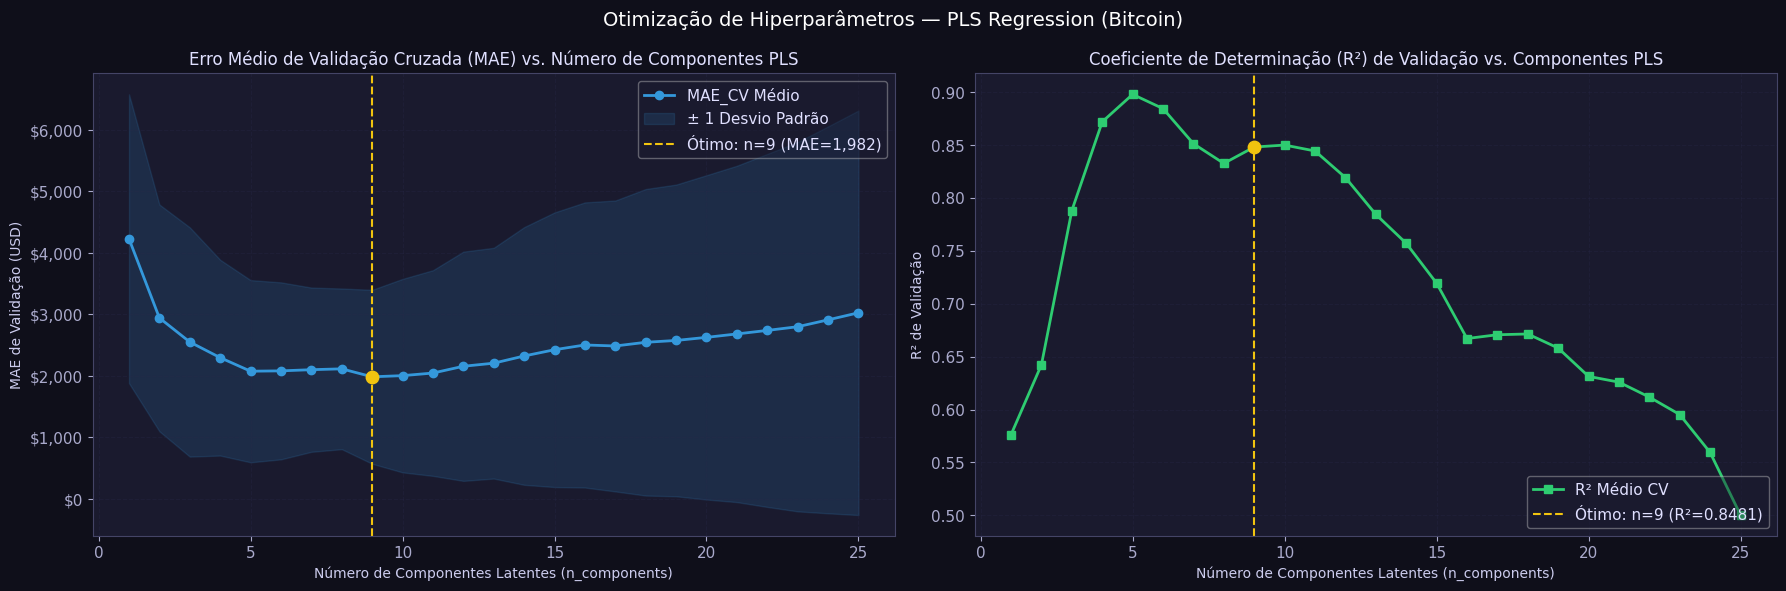

In [5]:
df_plot = df_grid.sort_values('n_components')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='#0f0f1a')

# 1. Curva MAE_CV vs n_components
axes[0].plot(df_plot['n_components'], df_plot['mae_cv_mean'], marker='o', color='#3498db', lw=2, label='MAE_CV Médio')
axes[0].fill_between(df_plot['n_components'], 
                     df_plot['mae_cv_mean'] - df_plot['mae_cv_std'], 
                     df_plot['mae_cv_mean'] + df_plot['mae_cv_std'], 
                     color='#3498db', alpha=0.15, label='± 1 Desvio Padrão')
axes[0].axvline(best_config['n_components'], color='#f1c40f', ls='--', lw=1.5, 
                label=f"Ótimo: n={int(best_config['n_components'])} (MAE={best_config['mae_cv_mean']:,.0f})")
axes[0].scatter([best_config['n_components']], [best_config['mae_cv_mean']], color='#f1c40f', s=80, zorder=5)
axes[0].set_title('Erro Médio de Validação Cruzada (MAE) vs. Número de Componentes PLS', color='#e0e0ff', fontsize=12)
axes[0].set_xlabel('Número de Componentes Latentes (n_components)', fontsize=10)
axes[0].set_ylabel('MAE de Validação (USD)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', framealpha=0.4)

# 2. Curva R² CV vs n_components
axes[1].plot(df_plot['n_components'], df_plot['r2_cv_mean'], marker='s', color='#2ecc71', lw=2, label='R² Médio CV')
axes[1].axvline(best_config['n_components'], color='#f1c40f', ls='--', lw=1.5, 
                label=f"Ótimo: n={int(best_config['n_components'])} (R²={best_config['r2_cv_mean']:.4f})")
axes[1].scatter([best_config['n_components']], [best_config['r2_cv_mean']], color='#f1c40f', s=80, zorder=5)
axes[1].set_title('Coeficiente de Determinação (R²) de Validação vs. Componentes PLS', color='#e0e0ff', fontsize=12)
axes[1].set_xlabel('Número de Componentes Latentes (n_components)', fontsize=10)
axes[1].set_ylabel('R² de Validação', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower right', framealpha=0.4)

fig.suptitle('Otimização de Hiperparâmetros — PLS Regression (Bitcoin)', color='#ffffff', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_01_gridsearch.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 4. Ajuste do Modelo Final no Conjunto de Treino Completo e Análise de Pesos

Ajustamos o modelo PLS com o número ótimo de componentes (`n_components = 9`) sobre todo o conjunto de treino (1.996 observações). Avaliamos os coeficientes de regressão atribuídos a cada feature.

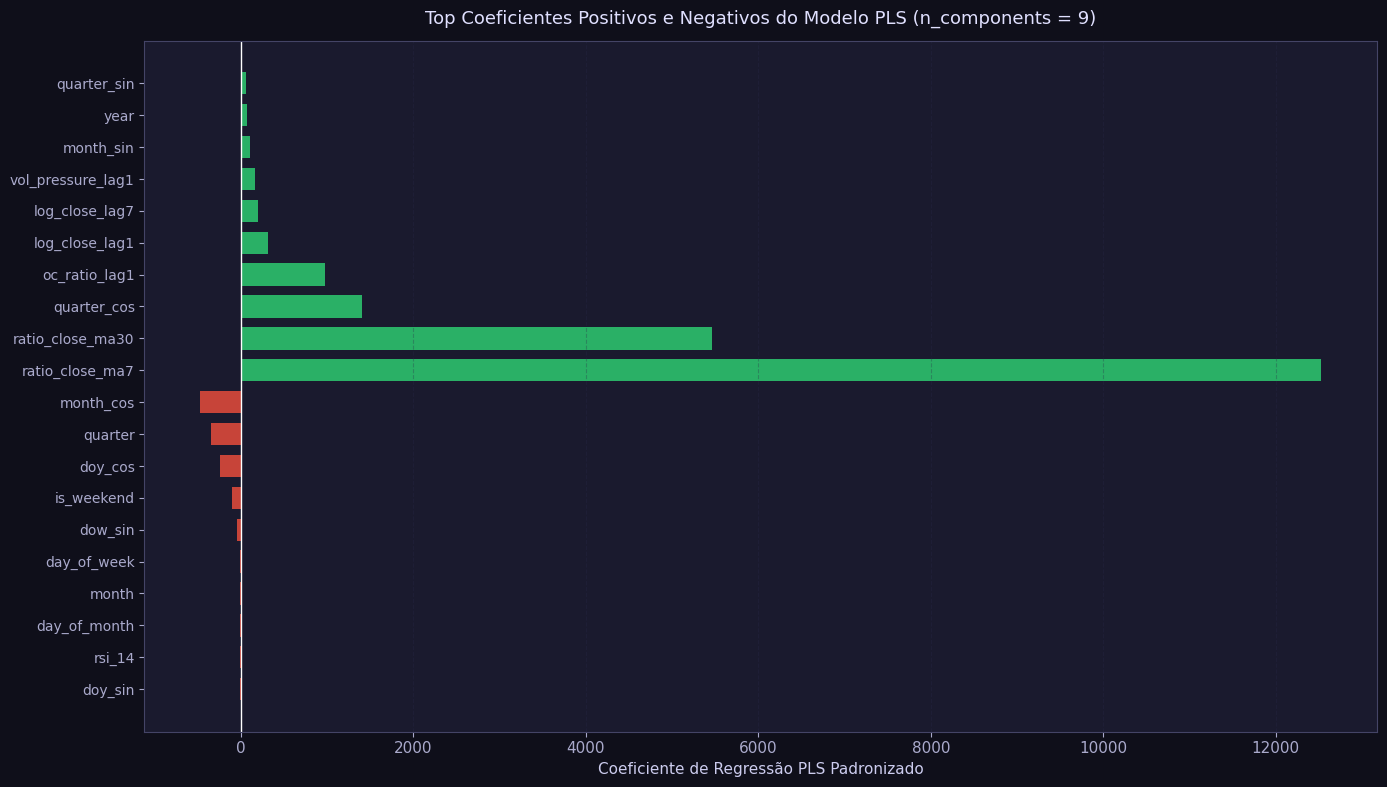

Top 5 Maiores Coeficientes Positivos:
ratio_close_ma7     12523.9550
ratio_close_ma30     5465.7838
quarter_cos          1406.4505
oc_ratio_lag1         968.1683
log_close_lag1        311.8119
dtype: float64

Top 5 Maiores Coeficientes Negativos:
dow_sin       -49.7771
is_weekend   -107.2563
doy_cos      -243.6860
quarter      -346.0166
month_cos    -469.9954
dtype: float64


In [6]:
optimal_n_comp = int(best_config['n_components'])

pls_final = PLSRegression(n_components=optimal_n_comp, scale=True)
pls_final.fit(X_train, y_train)

# Coeficientes do modelo PLS
coefs = pd.Series(pls_final.coef_.ravel(), index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0f0f1a')
top_pos = coefs.head(10)
top_neg = coefs.tail(10)
top_coefs = pd.concat([top_neg, top_pos])

cores = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_coefs.values]
ax.barh(range(len(top_coefs)), top_coefs.values, color=cores, alpha=0.85, height=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs.index, fontsize=10)
ax.axvline(0, color='#ffffff', ls='-', lw=1)
ax.set_xlabel('Coeficiente de Regressão PLS Padronizado', fontsize=11)
ax.set_title(f'Top Coeficientes Positivos e Negativos do Modelo PLS (n_components = {optimal_n_comp})', 
             color='#e0e0ff', fontsize=13, pad=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_02_variancia_explicada.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("Top 5 Maiores Coeficientes Positivos:")
print(top_pos.head(5).round(4))
print("\nTop 5 Maiores Coeficientes Negativos:")
print(top_neg.tail(5).round(4))

## 5. Exportação da Configuração Otimizada

In [7]:
config_export = {
    'modelo': 'PLS_Regression',
    'base': 'bitcoin',
    'alvo': target_col,
    'n_features': len(FEATURE_COLS),
    'n_train': int(len(X_train)),
    'data_corte': meta['data_corte'],
    'random_state': RANDOM_STATE,
    'train_ratio': meta['train_ratio'],
    'n_components': optimal_n_comp,
    'scale': True,
    'mae_cv': float(best_config['mae_cv_mean']),
    'mae_cv_std': float(best_config['mae_cv_std']),
    'rmse_cv': float(best_config['rmse_cv_mean']),
    'r2_cv': float(best_config['r2_cv_mean']),
    'metodo_selecao': 'TimeSeriesSplit (5 folds), criterio MAE_CV'
}

with open(OUTPUT_DIR / 'pls_config_final.json', 'w', encoding='utf-8') as f:
    json.dump(config_export, f, indent=2, ensure_ascii=False)

print('Exportações concluídas com sucesso:')
print('  pls_gridsearch_resultados.csv — resultados detalhados de cada componente')
print('  pls_config_final.json         — configuração selecionada para o Walk-Forward')
print('  plot_PLS_01_gridsearch.png')
print('  plot_PLS_02_variancia_explicada.png')

Exportações concluídas com sucesso:
  pls_gridsearch_resultados.csv — resultados detalhados de cada componente
  pls_config_final.json         — configuração selecionada para o Walk-Forward
  plot_PLS_01_gridsearch.png
  plot_PLS_02_variancia_explicada.png
